In [47]:
from dotenv import load_dotenv
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_mistralai import ChatMistralAI, MistralAIEmbeddings
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_community.vectorstores import FAISS
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from typing import Annotated, TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, BaseMessage, SystemMessage
from langgraph.prebuilt import ToolNode, tools_condition
import requests

In [3]:
llm = ChatMistralAI(model="mistral-large-latest")

In [8]:
loader = PyPDFLoader("thebook.pdf") 
docs = loader.load()

In [9]:
len(docs)

234

In [29]:
splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
chunks = splitter.split_documents(docs)

In [11]:
len(chunks)

566

In [31]:
embeddings = MistralAIEmbeddings(model="mistral-embed")
vector_store = FAISS.from_documents(chunks, embeddings)




In [32]:
vector_store


In [33]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k':4})

In [ ]:
retriever.invoke('What is a decision tree')[0]

Document(id='ab30412b-a799-4976-b548-ba8307f5b3a7', metadata={'producer': 'pdfTeX-1.40.10', 'creator': 'LaTeX with hyperref package', 'creationdate': '2010-10-01T15:47:05-07:00', 'author': 'AlexJ.SmolaandVishyS.V.N.Vishwanathan', 'title': 'AnIntroductiontoMachineLearning', 'subject': '', 'keywords': '', 'moddate': '2010-10-01T15:47:05-07:00', 'trapped': '/False', 'ptex.fullbanner': 'This is pdfTeX, Version 3.1415926-1.40.10-2.2 (TeX Live/MacPorts 2009_6) kpathsea version 5.0.0', 'source': 'thebook.pdf', 'total_pages': 234, 'page': 10, 'page_label': '3'}, page_content='1\nIntroduction\nOver the past two decades Machine Learning has become one of the main-\nstays of information technology and with that, a rather central, albeit usually\nhidden, part of our life. With the ever increasing amounts of data becoming\navailable there is good reason to believe that smart data analysis will become\neven more pervasive as a necessary ingredient for technological progress.\nThe purpose of this cha

In [34]:
@tool
def rag_tool(query):

    """  
    Retrieve relevant information from the pdf document.
    Use this tool when the user asks factual / conceptual questions
    that might be answered from the stored ducuments.
    """

    result = retriever.invoke(query)

    context = [doc.page_content for doc in result]
    metadata = [doc.metadata for doc in result]

    return {
        'query': query,
        'context': context,
        'metadata': metadata
    }

search_tool = DuckDuckGoSearchRun(region="us-en")


@tool
def calculator(first_num: float, second_num: float, operation: str) -> dict:
    """
    Perform a basic arithmetic operation on two numbers.
    Supported operations: add, sub, mul, div
    """
    try:
        if operation == "add":
            result = first_num + second_num
        elif operation == "sub":
            result = first_num - second_num
        elif operation == "mul":
            result = first_num * second_num
        elif operation == "div":
            if second_num == 0:
                return {"error": "Division by zero is not allowed"}
            result = first_num / second_num
        else:
            return {"error": f"Unsupported operation '{operation}'"}

        return {
            "first_num": first_num,
            "second_num": second_num,
            "operation": operation,
            "result": result,
        }
    except Exception as e:
        return {"error": str(e)}




@tool
def get_stock_price(symbol: str) -> dict:
    """
    Fetch latest stock price for a given symbol (e.g. 'AAPL', 'TSLA') 
    using Alpha Vantage with API key in the URL.
    """
    url = (
        "https://www.alphavantage.co/query"
        f"?function=GLOBAL_QUOTE&symbol={symbol}&apikey=VVT9DNVQK704GREC"
    )
    r = requests.get(url)
    return r.json()


In [35]:
tools = [rag_tool, calculator, search_tool, get_stock_price]

llm_with_tools = llm.bind_tools(tools)


In [36]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [45]:
def chat_node(state: ChatState):


    system_message = SystemMessage(
        content=(
            "You are a helpful assistant. For questions about the uploaded PDF, call "
            "the `rag_tool` "
            ". You can also use the web search, stock price, and "
            "calculator tools when helpful."
        )
    )
    messages = [system_message, *state['messages']]

    response = llm_with_tools.invoke(messages)

    return {'messages': [response]}

In [38]:
tool_node = ToolNode(tools)

In [59]:
graph = StateGraph(ChatState)

graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges(
    "chat_node",
    tools_condition,
    {
        "tools": "tools",
        "__end__": END
    }
)
graph.add_edge('tools', 'chat_node')

chatbot = graph.compile()

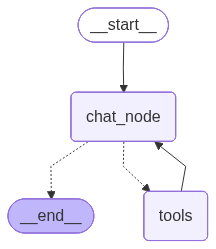

In [40]:
chatbot

In [60]:
result = chatbot.invoke(
    {
        "messages":[
            HumanMessage(
                content=(
                    "summarise the pdf"
                )
            )
        ]
    }
)

In [62]:
print(result['messages'][-1].content)


# result

Here is a concise summary of the key points from the PDF **"An Introduction to Machine Learning"** by Alex J. Smola and Vishy S.V.N. Vishwanathan:

---

### **Summary**
1. **Purpose of the Book**:
   - The book provides an introduction to machine learning, focusing on accessible explanations and practical applications rather than original research references. Readers are encouraged to explore cited works for deeper historical context.

2. **Key Applications of Machine Learning**:
   - **Recommendation Systems**:
     - Used by platforms like Amazon and Netflix to predict user preferences based on past behavior (e.g., purchases, views).
     - Relies on collaborative filtering, where user behavior is compared with similar users to make recommendations.
   - **Named Entity Recognition (NER)**:
     - Identifies entities such as names, places, titles, and actions in documents.
     - Used in applications like email clients (e.g., Apple’s Mail.app) to automatically extract and organize inf